# **Topic 2 — Mathematical Transformations**

## **Subtopic 2.1 — Why Do We Need Mathematical Transformations?**

Sometimes a feature exists, but its values are not in a form that helps the model learn well.

### Example

| Income    |
| --------- |
| 10,000    |
| 20,000    |
| 30,000    |
| 5,000,000 |

**Notice:**
* 10000
* 20000
* 30000
* 5000000

One value is extremely large compared to the others.

This can create problems.


#### **Problem 1 — Large Value Range**

| Salary    |
| --------- |
| 20,000    |
| 30,000    |
| 40,000    |
| 5,000,000 |

* The model may focus too much on the huge value.
* We often transform the feature to reduce the range.

#### **Problem 2 — Non-Linear Relationships**

| Area | Price |
| ---- | ----- |
| 1000 | 10L   |
| 2000 | 40L   |
| 3000 | 90L   |

Relationship:
* `Price ≈ Area²`

* This is not a straight-line relationship.
* Many models perform better when relationships become more linear.
* So we transform features.


#### **Problem 3 — Skewed Data**

Consider annual income:

Most people:
* 20k
* 25k
* 30k
* 35k

Few people:
* 5 lakh
* 10 lakh
* 50 lakh

Graph would look like:

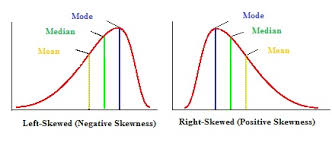

The above data will show right skewness.

**Many ML algorithms work better when the distribution is less skewed.**

### **What Does a Transformation Do?**

A transformation applies a mathematical operation to a feature.

General idea:

* Old Feature
*       ↓
* Mathematical Function
*       ↓
* New Feature

Examples:
* x
* log(x)
* sqrt(x)
* x²
* 1/x

#### **Example**

| Income |
| ------ |
| 1000   |
| 10000  |
| 100000 |

Apply logarithm:

| Income | Log(Income) |
| ------ | ----------- |
| 1000   | 3           |
| 10000  | 4           |
| 100000 | 5           |

Notice:
* 1000      → 3
* 10000     → 4
* 100000    → 5

**The huge differences became much smaller.**

## **Important Note**

* Transformation does not add new information.
* It changes how existing information is represented.

Example:

* `Height = 180 cm`

and

* `Height = 1.8 m`

Same information.

Different representation.

**Transformations often help models understand patterns more easily.**

## **Subtopic 2.2 — Log Transformation**

### **What is a Log Transformation?**

**A log transformation applies the logarithm function to a feature.**

* `New Feature = log(Old Feature)`

Commonly:

* `log(x)`

or in Python:

* `np.log(x)`

and more commonly:

* `np.log1p(x)`

**(log1p(x) means log(1+x))**

###  Why Is This Useful?

| Income    |
| --------- |
| 20,000    |
| 25,000    |
| 30,000    |
| 50,000    |
| 5,000,000 |

* The last value is extremely large.
* Many models struggle when a few values dominate the scale.

After log transformation:

| Income    | Log Value |
| --------- | --------- |
| 20,000    | 9.90      |
| 25,000    | 10.13     |
| 30,000    | 10.31     |
| 50,000    | 10.82     |
| 5,000,000 | 15.42     |

**The extreme value is still larger, but not ridiculously larger.**


#### **Intuition**

Imagine a ruler.

**Original ruler:**

* `0 ------------------------------------ 5,000,000`

Most data gets squeezed near the start.

**Log ruler:**

* `0 ----------- ----------- ----------- ----------- `

**The values become more spread out and easier for the model to analyze.**


### **When Should We Use Log Transformation?**

#### **Case 1: Right-Skewed Data**

**Example:**

* Income
* House Prices
* Website Visitors
* Product Sales
* Population

Distribution:

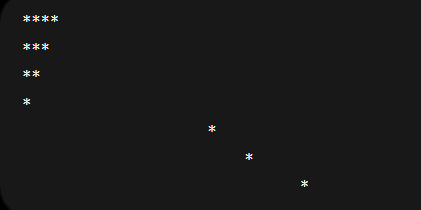

* Long tail on the right side.
* Log transformation often helps.

#### **Case 2: Large Value Ranges**

| Revenue   |
| --------- |
| 1,000     |
| 10,000    |
| 100,000   |
| 1,000,000 |

**Log transformation compresses the scale.**



### Python Implementation

Using NumPy:

`import numpy as np`

`df["Log_Income"] = np.log(df["Income"])`

**Safer version:**

`df["Log_Income"] = np.log1p(df["Income"])`


#### **Why Use log1p() Instead of log()?**

**Because:**

* `log(0)`

is undefined.

It causes an error.

**But:**

* `log(1 + 0) = log(1) = 0`

### **Important Limitation**

Log transformation cannot handle negative values directly.

**Example:**

* 10   ✓
* 50   ✓
* 0    ✓ using log1p
*
* -10 ✗
* -50 ✗
*
For negative values we need other techniques.

## **Subtopic 2.3 — Square Root Transformation**

### **What is Square Root Transformation?**

**Example**

| x  | √x |
| -- | -- |
| 1  | 1  |
| 4  | 2  |
| 9  | 3  |
| 16 | 4  |
| 25 | 5  |

**Python:**

`import numpy as np`

`df["sqrt_feature"] = np.sqrt(df["feature"])`


### **Why Use Square Root Transformation?**

Like log transformation, it compresses large values.

But:

**`Square Root Compression < Log Compression`**

Meaning:
* Log = stronger compression
* Square Root = gentler compression

### **Compare Log vs Square Root**

| x     |
| ----- |
| 100   |
| 1000  |
| 10000 |

**Square Root:**

| x     | √x   |
| ----- | ---- |
| 100   | 10   |
| 1000  | 31.6 |
| 10000 | 100  |

**Log:**

| x     | log(x) |
| ----- | ------ |
| 100   | 4.6    |
| 1000  | 6.9    |
| 10000 | 9.2    |

Square Root:
10000 → 100

Log:
10000 → 9.2

**Log compresses much more.**

### **When Should We Use Square Root?**

#### Case 1: Moderately Right-Skewed Data

**Not every skewed dataset needs log.**

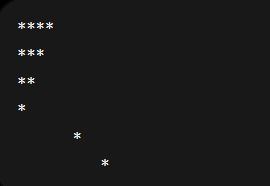

* Small tail.
* Square root may be enough.

#### **Case 2: Count Data**

**Very common examples:**

* Number of purchases
* Number of website visits
* Number of clicks
* Number of transactions

## **Important Difference from Log**

Log Cannot Handle Negatives
* `log(-5)`

Invalid.

Square Root Cannot Handle Negatives Either
* `√(-5)`

Invalid (for normal ML datasets).

**So both usually require:**

* `x ≥ 0`

* Very Large skewness -> Use Log
* Moderate skewness -> Use Square root

## **Subtopic 2.4 — Square Transformation**

This transformation is very different from Log and Square Root.

Those transformations:

`Compressed values`

Square transformation:

`Expands values`

### **What is Square Transformation?**

| x | x² |
| - | -- |
| 1 | 1  |
| 2 | 4  |
| 3 | 9  |
| 4 | 16 |
| 5 | 25 |

`df["feature_squared"] = df["feature"] ** 2`

## **Why Would We Ever Want This?**

Because sometimes the relationship between a feature and target is not linear.

**Example**

| Hours Studied | Marks |
| ------------- | ----- |
| 1             | 10    |
| 2             | 40    |
| 3             | 90    |
| 4             | 160   |

Observe:

* `Marks = 10 × Hours²`

The pattern is quadratic.

If we only give:

* `Hours`

a linear model struggles.

But if we create:

* `Hours²`

the relationship becomes much easier to learn.

### **Intuition**

Suppose we are predicting car braking distance.

Speed:

| Speed |
| ----- |
| 20    |
| 40    |
| 60    |


Braking distance often increases roughly with:

* `Speed²`

because physics tells us stopping distance grows rapidly with speed.

So:

* Speed
* ↓
* Speed²
*
can become a useful feature.

### **Very Important Concept**

Feature creation often uses:

* x
* x²
* x³

**to help models learn curved relationships**.

This is called:

**Polynomial Features**

### **When Should We Use Square Transformation?**

#### **Case 1: Quadratic Relationships**

When the target grows faster and faster.

**Example:**

* x = 1 → y = 1
* x = 2 → y = 4
* x = 3 → y = 9
* x = 4 → y = 16

**Pattern:**
* y = x²

#### **Case 2: Polynomial Feature Engineering**

Very common in:

* Linear Regression
* Polynomial Regression
* Kaggle competitions

Example:

`df["Age_squared"] = df["Age"] ** 2`

### **Important Warning**

Square transformation can increase the impact of outliers.

**Example:**

| x   |
| --- |
| 5   |
| 6   |
| 7   |
| 100 |

**After squaring:**

| x²    |
| ----- |
| 25    |
| 36    |
| 49    |
| 10000 |


The outlier became extremely dominant.

So use it only when there's a meaningful quadratic relationship.

## **Subtopic 2.5 — Reciprocal Transformation**

This is the least commonly used transformation among the ones we've covered, but it can be very useful when there is an inverse relationship.

### What is Reciprocal Transformation?

We replace each value with:

**1/x**

Python:

`df["reciprocal_feature"] = 1 / df["feature"]`

### **Why Use Reciprocal Transformation?**

Sometimes the relationship between a feature and target looks like:

* `Large increase at first
* Then smaller and smaller increases`

or

* `As x increases,
* y decreases`

This is called an **inverse relationship**.

### **Example: Speed and Travel Time**

**Suppose distance is fixed at 100 km.**

| Speed (km/h) | Time (h) |
| ------------ | -------- |
| 25           | 4        |
| 50           | 2        |
| 100          | 1        |

Relationship:

`Time = Distance / Speed`

Since distance is constant:

`Time ∝ 1/Speed`

**The reciprocal transformation captures this naturally.**

### **Intuition**

Imagine:

* x = Number of Workers
* y = Days Needed

As workers increase:

* Workers ↑
* Days ↓

The relationship is not linear.

Creating:

`1 / Workers`

can make the pattern easier for a model to learn.

### **Important Limitation**

What happens if:

`x = 0
`
Then:

`1/0`

is **undefined**.

So reciprocal transformation cannot be applied directly when zeros exist.

Example:

| x |
| - |
| 0 |
| 2 |
| 5 |

Problem:

**1/0 ❌**

You must handle zeros first.

## **Subtopic 2.6 — When to Use Which Transformation?**

In real projects, you won't think:

* `"I want to use Log."`

Instead you'll think:

* `"What problem does my feature have?"`

**Then choose the transformation.**

### **Decision 1: Is the data heavily right-skewed?**

| Income |
| ------ |
| 20k    |
| 25k    |
| 30k    |
| 40k    |
| 5M     |

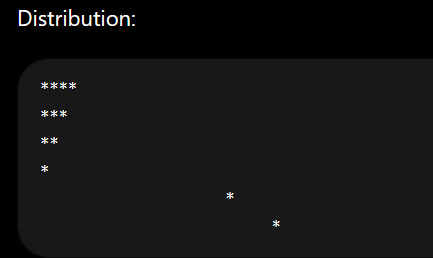

**Use:**
* `Log Transformation`
* `np.log1p(x)`

**Common examples:**
* Income
* Revenue
* House Prices
* Population
* Sales

### **Decision 2: Is the data moderately right-skewed?**

| Purchases |
| --------- |
| 1         |
| 2         |
| 3         |
| 10        |
| 20        |

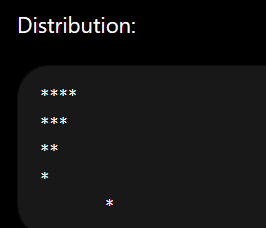

**Use:**

* `Square Root Transformation`
* `np.sqrt(x)`

**Common examples:**
* Counts
* Clicks
* Purchases
* Visits

### **Decision 3: Is the relationship quadratic?**

| Hours | Marks |
| ----- | ----- |
| 1     | 10    |
| 2     | 40    |
| 3     | 90    |
| 4     | 160   |

Looks like:

* `Marks ∝ Hours²`

Use:

* `Square Transformation`
* `x ** 2`

or create a new feature:

* `df["Hours_squared"] = df["Hours"] ** 2`

### **Decision 4: Is the relationship inverse?**

| Speed | Time |
| ----- | ---- |
| 25    | 4    |
| 50    | 2    |
| 100   | 1    |

Looks like:

* `Time ∝ 1/Speed`

Use:

* `Reciprocal Transformation
* 1/x`

or

* `1/(x+1)`

if zeros exist.

### **Decision 5: Does the feature already look good?**

| Age |
| --- |
| 21  |
| 24  |
| 28  |
| 32  |
| 35  |

**Distribution is already reasonable.**

Then:

**Do Nothing**

Many beginners transform everything.

That is a mistake.

## **Visual Cheat Sheet**

* Feature Problem
*        ↓
*
* Heavy Right Skew
*        ↓
* Log
*
* Moderate Right Skew
*        ↓
* Square Root
*
* Quadratic Relationship
*        ↓
* Square
*
* Inverse Relationship
*        ↓
* Reciprocal
*
* No Problem
*        ↓
* Leave As Is